In [5]:
import sys
sys.path.append("../src")
from pprint import pprint
from pathlib import Path
import numpy as np

# Analysis of confidence scores for each category

Categories classification confidence : The confidence seems to be variable. We need to explore repetitions of the same dataset to see if the confidence is consistent.
  * [ ] Explore confidence variability
  * [ ] Sample 10 datasets and generate 30 classifications for each dataset
  * [ ] For all categories, plot the distribution of confidence
  * [ ] See if this distribution is consistent across datasets
  * [ ] See if this distribution is consistent across ranges of confidence

In [6]:
# Load datasets from dryad

from dryad_api import search_datasets
import pickle
from pathlib import Path

datasets_pickle = "data/datasets.pickle"

if Path(datasets_pickle).exists():
    with open(datasets_pickle, "rb") as f:
        datasets = pickle.load(f)
else:
    datasets = search_datasets(["quebec ecology"], per_page=100)
    with open(datasets_pickle, "wb") as f:
        pickle.dump(datasets, f)

In [7]:
from gpt_extract import extract_from_text
from dotenv import load_dotenv
from pathlib import Path
import pickle
import pandas as pd

# Running the classification on 10 first abstracts, 10 times each

N_ABSTRACTS = 10
N_RUNS = 20

load_dotenv()

def assert_categories(classification):
    try:
        classification = classification["response"]
        assert isinstance(classification, dict)
        assert "categories" in classification
        categories = classification["categories"]
        assert isinstance(categories, dict)
        # Assert length
        assert len(categories) > 0
        # Assert values
        for category, confidence in categories.items():
            assert isinstance(category, str)
            assert isinstance(confidence, float)
            assert confidence >= 0 and confidence <= 1
        return True
    except AssertionError:
        return False

def run_classification(doi, abstract, n_runs=N_RUNS):
    out = {
        "doi": doi,
        "abstract": abstract,
        "classification": None,
        "failed_attempts": 0
    }
    max_tries = 5
    while out["failed_attempts"] < max_tries and not out["classification"]:
        classification = extract_from_text(abstract)
        valid_categories = assert_categories(classification)
        if classification and valid_categories:
            out["classification"] = classification
        else:
            out["failed_attempts"] += 1
    return out

pickle_path = "data/category_analysis_classification_gpt4_temp0.pickle"

if Path(pickle_path).exists():
    with open(pickle_path, "rb") as f:
        classification_results = pickle.load(f)
else:
    classification_results = []

def update_tracker(classification_results):
    run_tracker = {}
    for result in classification_results:
        try:
            doi = result["doi"]
            run_tracker[doi] += 1
        except KeyError:
            run_tracker[doi] = 1
    return run_tracker

run_tracker = update_tracker(classification_results)
for i, dataset in enumerate(datasets[:N_ABSTRACTS]):
    print(f"Running classification for {i+1}/{N_ABSTRACTS}")
    doi = dataset["identifier"]
    abstract = dataset["abstract"]
    try:
        doi_runs = run_tracker[doi]
    except KeyError:
        doi_runs = 0
    while doi_runs < N_RUNS:
        print(f"Running classification for {doi} ({doi_runs}/{N_RUNS})")
        classification_results.append(run_classification(doi, abstract))
        with open(pickle_path, "wb") as f:
            pickle.dump(classification_results, f)

        run_tracker = update_tracker(classification_results)
        doi_runs = run_tracker[doi]
    else:
        print(f"Skipping {doi} ({run_tracker[doi]}/{N_RUNS})")


Running classification for 1/10
Running classification for doi:10.5061/dryad.000000022 (0/20)
Running classification for doi:10.5061/dryad.000000022 (1/20)
Running classification for doi:10.5061/dryad.000000022 (2/20)
Running classification for doi:10.5061/dryad.000000022 (3/20)
Running classification for doi:10.5061/dryad.000000022 (4/20)
Running classification for doi:10.5061/dryad.000000022 (5/20)
Running classification for doi:10.5061/dryad.000000022 (6/20)
Running classification for doi:10.5061/dryad.000000022 (7/20)
Running classification for doi:10.5061/dryad.000000022 (8/20)
Running classification for doi:10.5061/dryad.000000022 (9/20)
Running classification for doi:10.5061/dryad.000000022 (10/20)
Running classification for doi:10.5061/dryad.000000022 (11/20)
Running classification for doi:10.5061/dryad.000000022 (12/20)
Running classification for doi:10.5061/dryad.000000022 (13/20)
Running classification for doi:10.5061/dryad.000000022 (14/20)
Running classification for doi:10

## Post processing the categories classification


In [11]:
list(classification_results[0]['classification']['response']['categories'].items())

[('abundances', 0.9), ('presence/absence', 0.8), ('trait data', 0.7)]

In [14]:
import pandas as pd

# Storing results in a datasets for further analysis
columns = ['doi', 'category', 'score']

df = pd.DataFrame(columns = columns)

# Limit to first 10 results per abstract

# Sort by doi
classification_results = sorted(classification_results, key=lambda x: x['doi'])

# Iterate over results, break when 10 results for a 
MAX_DOI = N_RUNS

doi_counts = {}
for result in classification_results:
    doi = result['doi']
    try:
        doi_counts[doi] += 1
    except KeyError:
        doi_counts[doi] = 1
    if doi_counts[doi] > MAX_DOI:
        continue
    for category, score in result['classification']['response']['categories'].items():
        df.loc[len(df)] = [doi, category, score]

# for result in classification_results:
#     for category, score in result['classification']['categories'].items():
#         df.loc[len(df)] = [result['doi'], category, score]

print(df.head())
sorted(df['category'].unique())

                           doi          category  score
0  doi:10.5061/dryad.000000022        abundances    0.9
1  doi:10.5061/dryad.000000022  presence/absence    0.8
2  doi:10.5061/dryad.000000022        trait data    0.7
3  doi:10.5061/dryad.000000022        abundances    0.9
4  doi:10.5061/dryad.000000022        trait data    0.8


['abundances',
 'plots',
 'population time-series',
 'presence/absence',
 'trait data']

### Are the scores provided by chat gpt-4 consistent or are they random?

I need to decide if I trust the classification scores. I trust them if they answer to two condifitions
- Is the classification high enough?
- Is the score from a deterministic process? (non-random)

c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


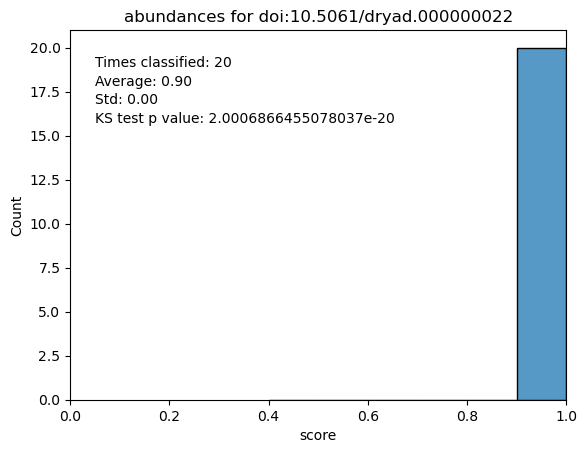

c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


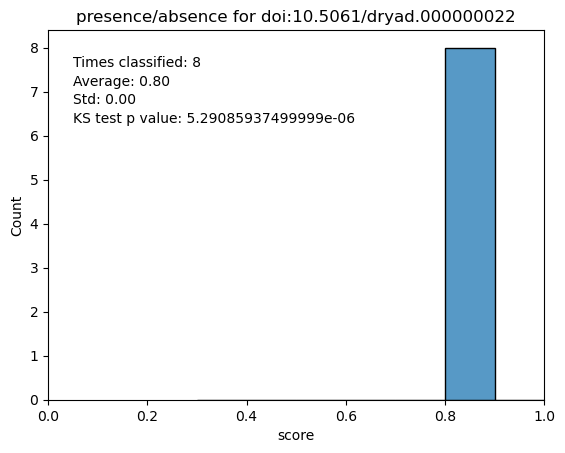

c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


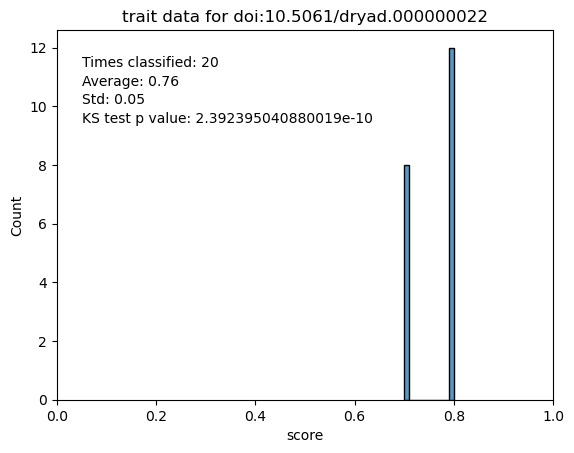

c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


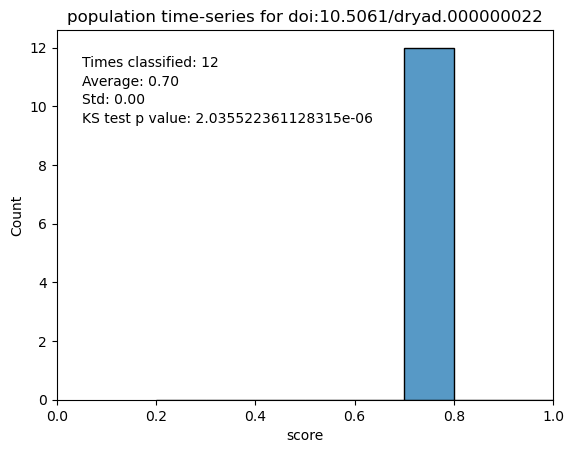

In [16]:
# For a single paper, show histograms of scores with colors by category
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kstest

doi = datasets[0]['identifier']

df_doi = df[df['doi'] == doi]

# Hists values for each category
for category in df_doi['category'].unique():
    df_category = df_doi[df_doi['category'] == category]
    sns.histplot(data=df_category, x="score", bins=10)
    plt.title(f"{category} for {doi}")
    plt.xlim(0, 1)
    # Show average and std as text in plot
    plt.text(0.05, 0.9, f"Times classified: {len(df_category)}", transform=plt.gca().transAxes)
    plt.text(0.05, 0.85, f"Average: {df_category['score'].mean():.2f}", transform=plt.gca().transAxes)
    plt.text(0.05, 0.8, f"Std: {df_category['score'].std():.2f}", transform=plt.gca().transAxes)

    # ks test
    ks_test = kstest(df_category['score'], 'uniform')
    pvalue = ks_test.pvalue
    plt.text(0.05, 0.75, f"KS test p value: {pvalue}", transform=plt.gca().transAxes)

    plt.show()


In [17]:
# For all doi and categories, and categories, compute average, std of scores and ks test p value

doi_cat_scores_columns = ['doi', 'category', 'hallucinated', 'n', 'average', 'std', 'ks_test_pvalue', 'ci_lower_95', 'ci_upper_95']

df_doi_cat_scores = pd.DataFrame(columns = doi_cat_scores_columns)

for doi in df['doi'].unique():
    df_doi = df[df['doi'] == doi]
    for category in df_doi['category'].unique():
        hallucinated = df_doi[df_doi['category'] == category]['hallucinated'].iloc[0]
        df_category = df_doi[df_doi['category'] == category]
        average = df_category['score'].mean()
        std = df_category['score'].std()
        ks_test = kstest(df_category['score'], 'uniform')
        pvalue = ks_test.pvalue
        # 95% confidence interval using t distribution
        n = len(df_category)
        t = 2.262 # t value for 95% confidence interval with n-1 degrees of freedom
        ci_lower = average - t * std / n**0.5
        ci_upper = average + t * std / n**0.5
        df_doi_cat_scores.loc[len(df_doi_cat_scores)] = [doi, category, hallucinated, n, average, std, pvalue, ci_lower, ci_upper]

df_doi_cat_scores.head(10)

,doi,category,hallucinated,n,average,std,ks_test_pvalue,ci_lower_95,ci_upper_95
0,doi:10.5061/dryad.000000022,abundances,False,20,0.900,2.278130e-16,2.000687e-20,0.900000,0.900000
1,doi:10.5061/dryad.000000022,presence/absence,False,8,0.800,0.000000e+00,5.290859e-06,0.800000,0.800000
2,doi:10.5061/dryad.000000022,trait data,False,20,0.760,5.026247e-02,2.392395e-10,0.734577,0.785423
3,doi:10.5061/dryad.000000022,population time-series,False,12,0.700,1.159590e-16,2.035522e-06,0.700000,0.700000
4,doi:10.5061/dryad.4767v,abundances,False,20,0.905,6.863327e-02,2.833913e-14,0.870285,0.939715
5,doi:10.5061/dryad.4767v,plots,False,20,0.795,7.591547e-02,2.392395e-10,0.756602,0.833398
6,doi:10.5061/dryad.4767v,trait data,False,20,0.775,7.863975e-02,2.392395e-10,0.735224,0.814776
7,doi:10.5061/dryad.5ff8m0q,population time-series,False,20,0.800,1.139065e-16,2.833913e-14,0.800000,0.800000
8,doi:10.5061/dryad.5ff8m0q,trait data,False,20,0.900,2.278130e-16,2.000687e-20,0.900000,0.900000
9,doi:10.5061/dryad.63fr7,trait data,False,20,0.900,2.278130e-16,2.000687e-20,0.900000,0.900000


c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.

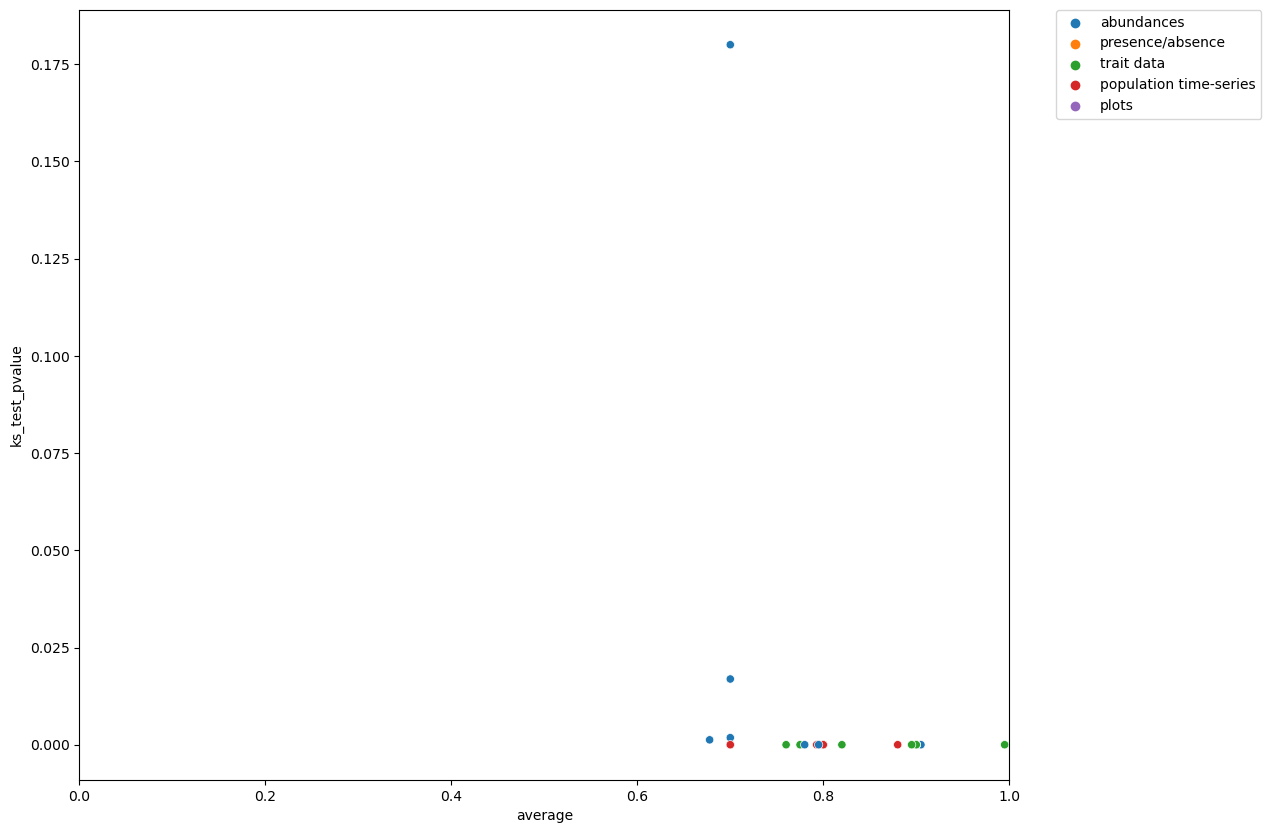

In [18]:
# Is there a correlation between the average score and the p value of the ks test?
figure = plt.figure(figsize=(12, 10))

# Use slightly larger black circles around halluncinated categories
sns.scatterplot(data=df_doi_cat_scores[df_doi_cat_scores['hallucinated']], x="average", y="ks_test_pvalue", color="black", marker="o", s=100)

# Use losange marker, and color by category
sns.scatterplot(data=df_doi_cat_scores, x="average", y="ks_test_pvalue", hue="category")


plt.xlim(0, 1)

# Show legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.

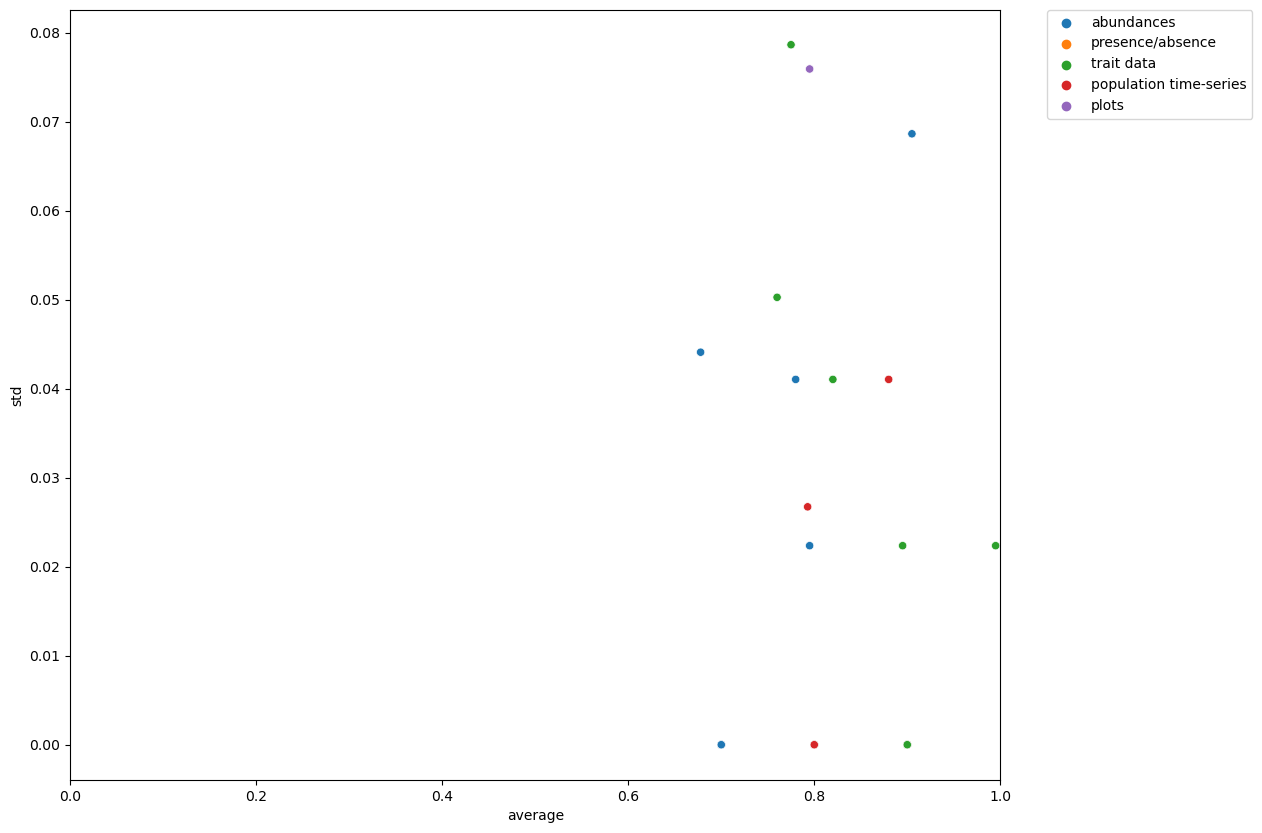

In [19]:
# Is there a correlation between the average score and the std of the ks test?
figure = plt.figure(figsize=(12, 10))

# Use slightly larger black circles around halluncinated categories
sns.scatterplot(data=df_doi_cat_scores[df_doi_cat_scores['hallucinated']], x="average", y="std", color="black", marker="o", s=100)
sns.scatterplot(data=df_doi_cat_scores, x="average", y="std", hue="category")

plt.xlim(0, 1)

# Show legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.

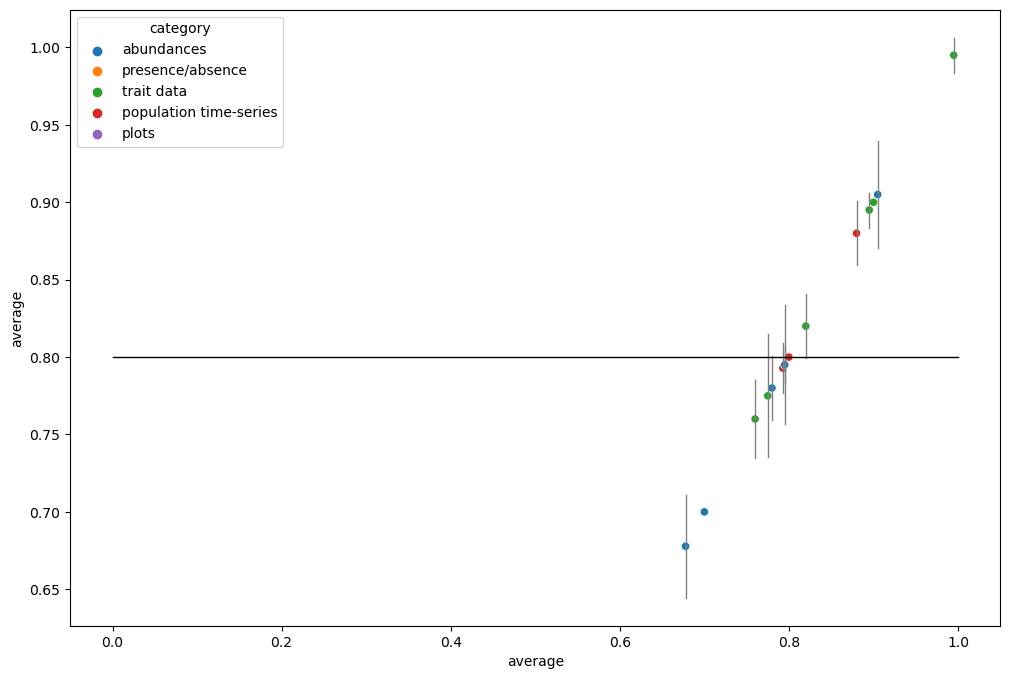

In [20]:
# Plot vertical lines for 95% confidence interval starting at (average, ci_lower) and ending at (average, ci_upper)
plt.figure(figsize=(12, 8))
for i, row in df_doi_cat_scores.iterrows():
    plt.plot([row['average'], row['average']], [row['ci_lower_95'], row['ci_upper_95']], color='grey', linestyle='-', linewidth=1)
    # Scatter plot of average average

sns.scatterplot(data=df_doi_cat_scores, x="average", y="average", hue="category")

# Horizontal line at 0.8
plt.plot([0, 1], [0.8, 0.8], color='black', linestyle='-', linewidth=1)

C:\Users\beav3503\AppData\Local\Temp\ipykernel_23904\1215065314.py:24: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[f"{ks_threshold_column}_no_hallucinated"].fillna(method="ffill", inplace=True)
C:\Users\beav3503\AppData\Local\Temp\ipykernel_23904\1215065314.py:27: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[f"{dev_threshold_column}_no_hallucinated"].fillna(method="ffill", inplace=True)
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version.

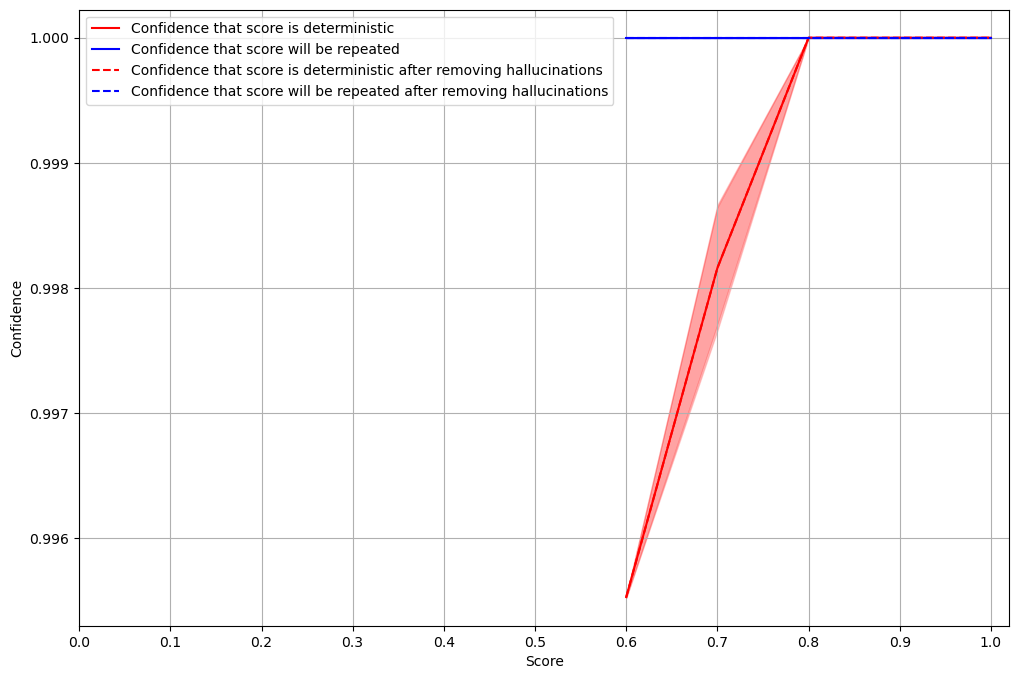

In [21]:
# What is a good threshold to choose to make sure that the classification is from a non-uniform distribution which score is close to the average

KS_THRESHOLD = 0.05
DEV_THRESHOLD = 0.15

ks_threshold_column = "confidence_threshold_ks_{}".format(str(KS_THRESHOLD).replace(".", ""))
dev_threshold_column = "confidence_dev_{}".format(str(DEV_THRESHOLD).replace(".", ""))


# Add dist_ks_pvalue to df
df["dist_ks_pvalue"] = df[["doi", "category"]].merge(df_doi_cat_scores[["doi", "category", "ks_test_pvalue"]], on=["doi", "category"], how="left")["ks_test_pvalue"]
df["dist_average"] = df[["doi", "category"]].merge(df_doi_cat_scores[["doi", "category", "average"]], on=["doi", "category"], how="left")["average"]
df["deviation"] = abs(df["score"] - df["dist_average"])

# Cumulative confidence on df sorted by score
df = df.sort_values(by=["score"], ascending=False)
df.reset_index(inplace=True, drop=True)
df[f"{ks_threshold_column}"] = (df["dist_ks_pvalue"] <= 0.05).expanding().mean()
df[f"{dev_threshold_column}"] = (df["deviation"] <= DEV_THRESHOLD).expanding().mean()

# Thresholds if excluding hallucinated categorie values

df.loc[df["hallucinated"] == False, f"{ks_threshold_column}_no_hallucinated"] = (df.loc[df["hallucinated"] == False, "dist_ks_pvalue"] <= 0.05).expanding().mean()
df[f"{ks_threshold_column}_no_hallucinated"].fillna(method="ffill", inplace=True)

df.loc[df["hallucinated"] == False, f"{dev_threshold_column}_no_hallucinated"] = (df.loc[df["hallucinated"] == False, "deviation"] <= DEV_THRESHOLD).expanding().mean()
df[f"{dev_threshold_column}_no_hallucinated"].fillna(method="ffill", inplace=True)


# Plot threshold curves with dashed lines for halluncinated categories and solid lines for non-hallucinated categories
# Plot blue for deviation and red for ks test
plt.figure(figsize=(12, 8))
sns.lineplot(data=df, x="score", y=f"{ks_threshold_column}", color="red", linestyle='-', label = "Confidence that score is deterministic")
sns.lineplot(data=df, x="score", y=f"{dev_threshold_column}", color="blue", linestyle='-', label = "Confidence that score will be repeated")
sns.lineplot(data=df, x="score", y=f"{ks_threshold_column}_no_hallucinated", color="red", linestyle='--', label = "Confidence that score is deterministic after removing hallucinations")
sns.lineplot(data=df, x="score", y=f"{dev_threshold_column}_no_hallucinated", color="blue", linestyle='--', label = "Confidence that score will be repeated after removing hallucinations")

plt.xticks(np.arange(0, 1.1, 0.1)) #Every 0.1

# Add grid
plt.grid()

plt.xlabel("Score")
plt.ylabel("Confidence")

plt.show()


c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating ins

<Axes: xlabel='score', ylabel='deviation'>

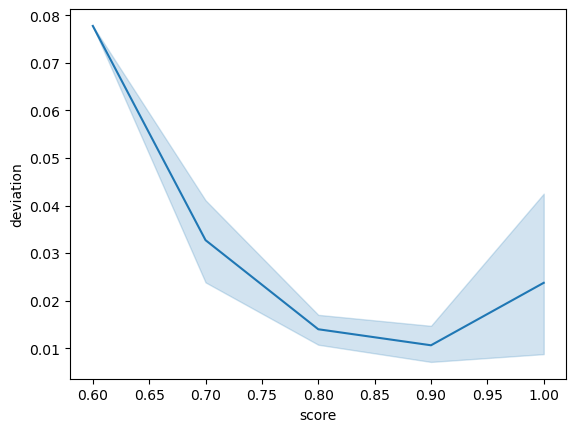

In [22]:
sns.lineplot(data=df, x="score", y="deviation")


Hallucinated Categories Show Random Score Distribution:

    The KS-test p-values for hallucinated categories are generally higher, often exceeding the threshold of 0.05.
    High p-values indicate a failure to reject the null hypothesis that the scores come from a uniform (random) distribution.
    This suggests that the model assigns scores to hallucinated categories in a random and inconsistent manner.

Increased Variability in Hallucinated Categories:

    Hallucinated categories exhibit higher standard deviations in their scores compared to valid categories.
    The greater variability implies less consistency in the model's confidence for these categories across multiple runs.

Lower Average Scores:

    The mean scores for hallucinated categories tend to be lower than those for valid categories.
    A lower average score indicates that the model is less confident in these classifications

In [23]:
# Sort by score and show the top 10
df.sort_values(by=['score'], ascending=False).head(20)

,doi,category,score,hallucinated,dist_ks_pvalue,dist_average,deviation,confidence_threshold_ks_005,confidence_dev_015,confidence_threshold_ks_005_no_hallucinated,confidence_dev_015_no_hallucinated
0,doi:10.5061/dryad.7tn01,trait data,1.0,False,1.907349e-26,0.995,0.005,1.0,1.0,1.0,1.0
13,doi:10.5061/dryad.4767v,abundances,1.0,False,2.833913e-14,0.905,0.095,1.0,1.0,1.0,1.0
1,doi:10.5061/dryad.7tn01,trait data,1.0,False,1.907349e-26,0.995,0.005,1.0,1.0,1.0,1.0
23,doi:10.5061/dryad.7tn01,trait data,1.0,False,1.907349e-26,0.995,0.005,1.0,1.0,1.0,1.0
21,doi:10.5061/dryad.7tn01,trait data,1.0,False,1.907349e-26,0.995,0.005,1.0,1.0,1.0,1.0
20,doi:10.5061/dryad.7tn01,trait data,1.0,False,1.907349e-26,0.995,0.005,1.0,1.0,1.0,1.0
19,doi:10.5061/dryad.4767v,abundances,1.0,False,2.833913e-14,0.905,0.095,1.0,1.0,1.0,1.0
18,doi:10.5061/dryad.7tn01,trait data,1.0,False,1.907349e-26,0.995,0.005,1.0,1.0,1.0,1.0
17,doi:10.5061/dryad.7tn01,trait data,1.0,False,1.907349e-26,0.995,0.005,1.0,1.0,1.0,1.0
16,doi:10.5061/dryad.4767v,abundances,1.0,False,2.833913e-14,0.905,0.095,1.0,1.0,1.0,1.0


In [24]:
## Question : Do halucinated classifications, presenting themselves as either typoed class names, or represents bad classification